C:\Users\Admin\AppData\Local\Temp\ipykernel_4888\2356710538.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_combined = df_combined.fillna(method='ffill')  # Điền giá trị thiếu bằng giá trị trước đó


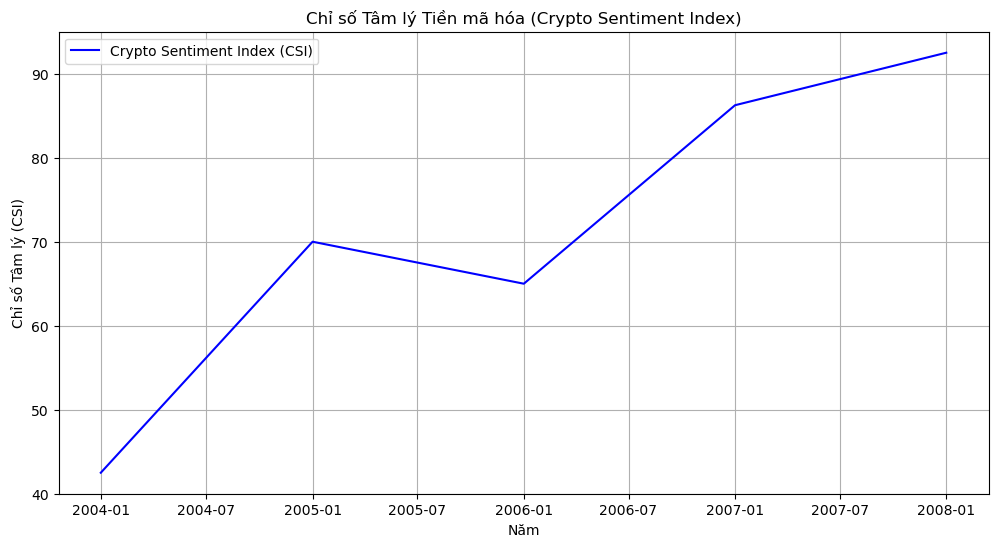

In [59]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Thiết lập thư mục chứa các file CSV
folder_path = "./TEST"  # Đổi đường dẫn tới thư mục chứa file CSV của bạn
files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# 2. Đọc tất cả dữ liệu từ Google Trends
df_list = []
for file in files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df.columns = ["date", file.replace(".csv", "")]  # Đổi tên cột theo từ khóa
    df["date"] = pd.to_datetime(df["date"], errors='coerce')  # Chuyển date thành datetime
    df.set_index("date", inplace=True)  # Đặt cột date làm index
    df = df.apply(pd.to_numeric, errors='coerce')  # Chuyển đổi dữ liệu về dạng số
    df = df.interpolate(method='linear')  # Điền giá trị thiếu bằng nội suy tuyến tính
    df_list.append(df)

# 3. Hợp nhất tất cả các file thành một DataFrame duy nhất
df_combined = pd.concat(df_list, axis=1)

# 4. Kiểm tra và xử lý dữ liệu lỗi
df_combined = df_combined.fillna(method='ffill')  # Điền giá trị thiếu bằng giá trị trước đó

# 5. Chuẩn hóa dữ liệu Google Trends theo từng tháng
def normalize_google_trends_iterative(df, start_date, end_date):
    df_rescaled = df.copy()

    # 5.1. Tìm mức đỉnh cao nhất trong giai đoạn chuẩn hóa ban đầu (ví dụ 2004-2010)
    initial_peak = df.loc[start_date:end_date].max().max()  # Đỉnh cao nhất từ start_date đến end_date
    df_rescaled.loc[start_date:end_date] = (df_rescaled.loc[start_date:end_date] / initial_peak) * 100

    # 5.2. Chuẩn hóa từng tháng sau giai đoạn chuẩn hóa ban đầu
    for month in df.index[df.index > pd.to_datetime(end_date)]:
        peak_so_far = df_rescaled.loc[start_date:month].max().max()  # Đỉnh cao nhất đến tháng hiện tại
        df_rescaled.loc[month] = (df.loc[month] / peak_so_far) * 100  # Tái định tỷ lệ

    return df_rescaled

# Đặt giai đoạn chuẩn hóa ban đầu (ví dụ từ 2004 đến 2010)
start_date = "2004-01-01"
end_date = "2005-01-01"

df_normalized = normalize_google_trends_iterative(df_combined, start_date, end_date)

# 6. Tính Chỉ số Tâm lý Tiền mã hóa (CSI)
df_normalized["CSI"] = df_normalized.mean(axis=1)  # Trung bình dữ liệu của tất cả từ khóa

# 7. Xuất file "new.csv" với chỉ 2 cột: date & interest (CSI)
df_csi = df_normalized[["CSI"]].reset_index()  # Đặt lại index để có cột "date"
df_csi.columns = ["date", "interest"]  # Đổi tên cột cho phù hợp
df_csi.to_csv("new.csv", index=False)  # Xuất dữ liệu ra file CSV

# 8. Vẽ biểu đồ Chỉ số CSI theo thời gian
plt.figure(figsize=(12, 6))
plt.plot(df_csi["date"], df_csi["interest"], label="Crypto Sentiment Index (CSI)", color='b')
plt.xlabel("Năm")
plt.ylabel("Chỉ số Tâm lý (CSI)")
plt.title("Chỉ số Tâm lý Tiền mã hóa (Crypto Sentiment Index)")
plt.legend()
plt.grid(True)
plt.show()

# 9. Lưu toàn bộ dữ liệu đã chuẩn hóa thành file CSV
df_normalized.to_excel("nè.xlsx")


C:\Users\Admin\AppData\Local\Temp\ipykernel_4888\1589801884.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_combined = df_combined.fillna(method='ffill')  # Điền giá trị thiếu bằng giá trị trước đó
C:\Users\Admin\AppData\Local\Temp\ipykernel_4888\1589801884.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[25.  50.  87.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_rescaled.loc[start_date:end_date] = (df_rescaled.loc[start_date:end_date] / initial_peak) * 100
C:\Users\Admin\AppData\Local\Temp\ipykernel_4888\1589801884.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[37.5 62.5 75. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

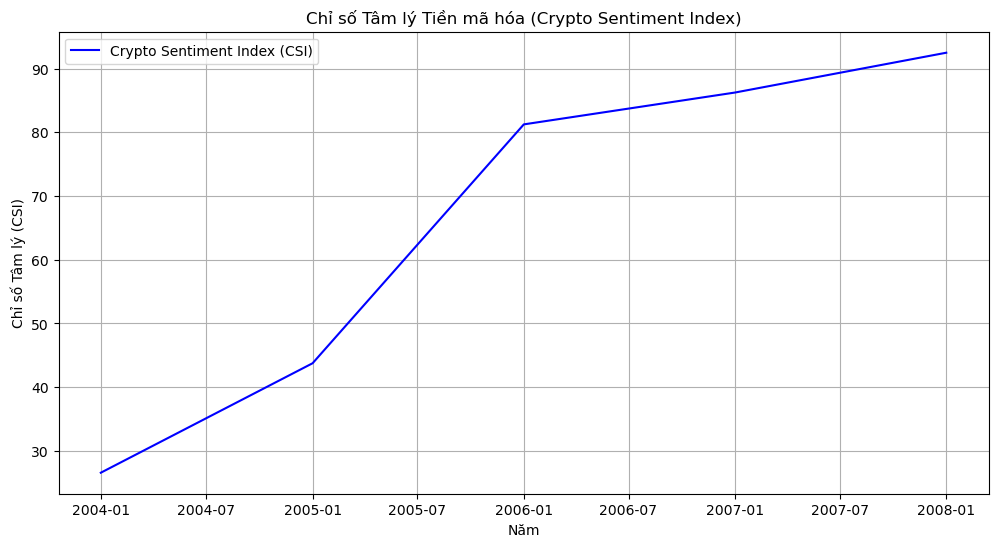

In [55]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Thiết lập thư mục chứa các file CSV
folder_path = "./TEST"  # Đổi đường dẫn tới thư mục chứa file CSV của bạn
files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# 2. Đọc tất cả dữ liệu từ Google Trends
df_list = []
for file in files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df.columns = ["date", file.replace(".csv", "")]  # Đổi tên cột theo từ khóa
    df["date"] = pd.to_datetime(df["date"], errors='coerce')  # Chuyển date thành datetime
    df.set_index("date", inplace=True)  # Đặt cột date làm index
    df = df.apply(pd.to_numeric, errors='coerce')  # Chuyển đổi dữ liệu về dạng số
    df = df.interpolate(method='linear')  # Điền giá trị thiếu bằng nội suy tuyến tính
    df_list.append(df)

# 3. Hợp nhất tất cả các file thành một DataFrame duy nhất
df_combined = pd.concat(df_list, axis=1)

# 4. Kiểm tra và xử lý dữ liệu lỗi
df_combined = df_combined.fillna(method='ffill')  # Điền giá trị thiếu bằng giá trị trước đó

# 5. Chuẩn hóa dữ liệu Google Trends theo từng tháng
def normalize_google_trends_iterative(df, start_date, end_date):
    df_rescaled = df.copy()

    # 5.1. Tìm mức đỉnh cao nhất trong giai đoạn chuẩn hóa ban đầu (ví dụ 2004-2010)
    initial_peak = df.loc[start_date:end_date].max().max()  # Đỉnh cao nhất từ start_date đến end_date
    df_rescaled.loc[start_date:end_date] = (df_rescaled.loc[start_date:end_date] / initial_peak) * 100

    # 5.2. Chuẩn hóa từng tháng sau giai đoạn chuẩn hóa ban đầu
    for month in df.index[df.index > pd.to_datetime(end_date)]:
        peak_so_far = df_rescaled.loc[start_date:month].max().max()  # Đỉnh cao nhất đến tháng hiện tại
        df_rescaled.loc[month] = (df.loc[month] / peak_so_far) * 100  # Tái định tỷ lệ

    return df_rescaled

# Đặt giai đoạn chuẩn hóa ban đầu (ví dụ từ 2004 đến 2010)
start_date = "2004-01-01"
end_date = "2006-01-01"

df_normalized = normalize_google_trends_iterative(df_combined, start_date, end_date)

# 6. Tính Chỉ số Tâm lý Tiền mã hóa (CSI)
df_normalized["CSI"] = df_normalized.mean(axis=1)  # Trung bình dữ liệu của tất cả từ khóa

# 7. Xuất file "new.csv" với chỉ 2 cột: date & interest (CSI)
df_csi = df_normalized[["CSI"]].reset_index()  # Đặt lại index để có cột "date"
df_csi.columns = ["date", "interest"]  # Đổi tên cột cho phù hợp
df_csi.to_csv("new.csv", index=False)  # Xuất dữ liệu ra file CSV

# 8. Vẽ biểu đồ Chỉ số CSI theo thời gian
plt.figure(figsize=(12, 6))
plt.plot(df_csi["date"], df_csi["interest"], label="Crypto Sentiment Index (CSI)", color='b')
plt.xlabel("Năm")
plt.ylabel("Chỉ số Tâm lý (CSI)")
plt.title("Chỉ số Tâm lý Tiền mã hóa (Crypto Sentiment Index)")
plt.legend()
plt.grid(True)
plt.show()

# 9. Lưu toàn bộ dữ liệu đã chuẩn hóa thành file CSV
df_normalized.to_excel("hi1.xlsx")


C:\Users\Admin\AppData\Local\Temp\ipykernel_4888\1083458929.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_combined = df_combined.fillna(method='ffill')  # Điền giá trị thiếu bằng giá trị trước đó
C:\Users\Admin\AppData\Local\Temp\ipykernel_4888\1083458929.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[50. 56. 62. 58. 60. 45. 42. 41. 49. 47. 56. 51. 49. 48. 47. 48. 52. 41.
 81. 50. 41. 46. 43. 41. 40. 46. 45. 44. 44. 40. 40. 41. 38. 42. 36. 36.
 38. 49. 45. 47. 46. 43. 44. 38. 46. 37. 38. 40. 37.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_rescaled.loc[start_date:end_date] = (df_rescaled.loc[start_date:end_date] / initial_peak) * 100
C:\Users\Admin\AppData\Local\Temp\ipykernel_4888\1083458929.py:33: FutureWarning: Setting an item of incompatible dty

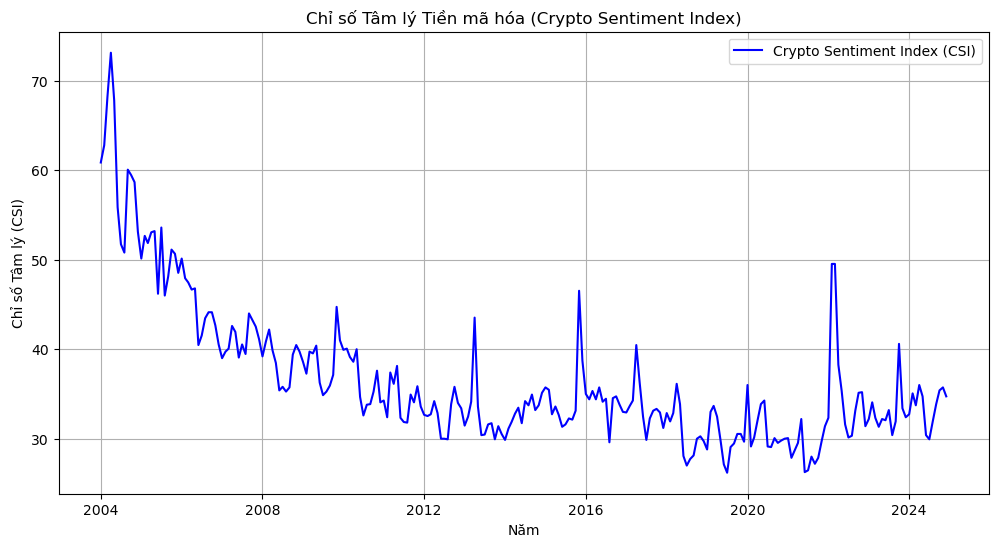

In [49]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Thiết lập thư mục chứa các file CSV
folder_path = "./DATA GG TREND"  # Đổi đường dẫn tới thư mục chứa file CSV của bạn
files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# 2. Đọc tất cả dữ liệu từ Google Trends
df_list = []
for file in files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df.columns = ["date", file.replace(".csv", "")]  # Đổi tên cột theo từ khóa
    df["date"] = pd.to_datetime(df["date"], errors='coerce')  # Chuyển date thành datetime
    df.set_index("date", inplace=True)  # Đặt cột date làm index
    df = df.apply(pd.to_numeric, errors='coerce')  # Chuyển đổi dữ liệu về dạng số
    df = df.interpolate(method='linear')  # Điền giá trị thiếu bằng nội suy tuyến tính
    df_list.append(df)

# 3. Hợp nhất tất cả các file thành một DataFrame duy nhất
df_combined = pd.concat(df_list, axis=1)

# 4. Kiểm tra và xử lý dữ liệu lỗi
df_combined = df_combined.fillna(method='ffill')  # Điền giá trị thiếu bằng giá trị trước đó

# 5. Chuẩn hóa dữ liệu Google Trends theo từng tháng
def normalize_google_trends_iterative(df, start_date, end_date):
    df_rescaled = df.copy()

    # 5.1. Tìm mức đỉnh cao nhất trong giai đoạn chuẩn hóa ban đầu (ví dụ 2004-2010)
    initial_peak = df.loc[start_date:end_date].max().max()  # Đỉnh cao nhất từ start_date đến end_date
    df_rescaled.loc[start_date:end_date] = (df_rescaled.loc[start_date:end_date] / initial_peak) * 100

    # 5.2. Chuẩn hóa từng tháng sau giai đoạn chuẩn hóa ban đầu
    for month in df.index[df.index > pd.to_datetime(end_date)]:
        peak_so_far = df_rescaled.loc[start_date:month].max().max()  # Đỉnh cao nhất đến tháng hiện tại
        df_rescaled.loc[month] = (df.loc[month] / peak_so_far) * 100  # Tái định tỷ lệ

    return df_rescaled

# Đặt giai đoạn chuẩn hóa ban đầu (ví dụ từ 2004 đến 2010)
start_date = "2004-01-01"
end_date = "2008-01-01"

df_normalized = normalize_google_trends_iterative(df_combined, start_date, end_date)

# 6. Tính Chỉ số Tâm lý Tiền mã hóa (CSI)
df_normalized["CSI"] = df_normalized.mean(axis=1)  # Trung bình dữ liệu của tất cả từ khóa

# 7. Xuất file "new.csv" với chỉ 2 cột: date & interest (CSI)
df_csi = df_normalized[["CSI"]].reset_index()  # Đặt lại index để có cột "date"
df_csi.columns = ["date", "interest"]  # Đổi tên cột cho phù hợp
df_csi.to_csv("new.csv", index=False)  # Xuất dữ liệu ra file CSV

# 8. Vẽ biểu đồ Chỉ số CSI theo thời gian
plt.figure(figsize=(12, 6))
plt.plot(df_csi["date"], df_csi["interest"], label="Crypto Sentiment Index (CSI)", color='b')
plt.xlabel("Năm")
plt.ylabel("Chỉ số Tâm lý (CSI)")
plt.title("Chỉ số Tâm lý Tiền mã hóa (Crypto Sentiment Index)")
plt.legend()
plt.grid(True)
plt.show()

# 9. Lưu toàn bộ dữ liệu đã chuẩn hóa thành file CSV
df_normalized.to_excel("hi.xlsx")


C:\Users\Admin\AppData\Local\Temp\ipykernel_4888\880304008.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_combined = df_combined.fillna(method='ffill')  # Điền giá trị thiếu bằng giá trị trước đó
C:\Users\Admin\AppData\Local\Temp\ipykernel_4888\880304008.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[68. 70. 70. 73. 66. 67. 72. 74. 69. 71. 70. 71. 70. 69. 82. 66. 66. 69.
 68. 69. 67. 68. 66. 68. 67. 67. 70. 67. 68. 68. 66. 70. 63. 66. 70. 69.
 69. 65. 66. 64. 64. 64. 62. 68. 61. 62. 63. 65. 63. 59. 63. 61. 61. 61.
 60. 61. 64. 60. 61. 62. 59. 58. 57. 58. 58. 60. 55. 59. 60. 59. 59. 59.
 58.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_rescaled.loc[start_date:end_date] = (df_rescaled.loc[start_date:end_date] / initial_peak) * 100
C:\Users\Admin\AppDat

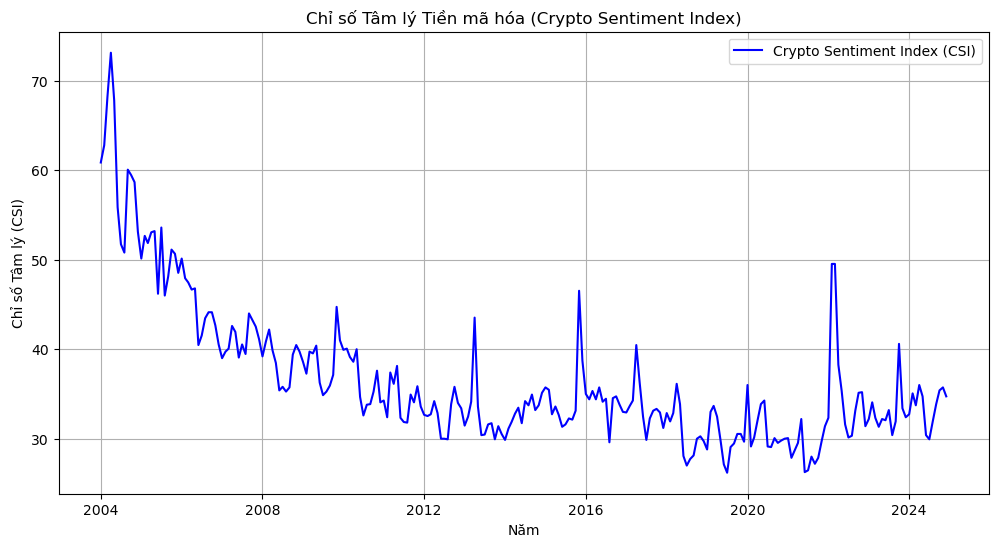

In [51]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Thiết lập thư mục chứa các file CSV
folder_path = "./DATA GG TREND"  # Đổi đường dẫn tới thư mục chứa file CSV của bạn
files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# 2. Đọc tất cả dữ liệu từ Google Trends
df_list = []
for file in files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df.columns = ["date", file.replace(".csv", "")]  # Đổi tên cột theo từ khóa
    df["date"] = pd.to_datetime(df["date"], errors='coerce')  # Chuyển date thành datetime
    df.set_index("date", inplace=True)  # Đặt cột date làm index
    df = df.apply(pd.to_numeric, errors='coerce')  # Chuyển đổi dữ liệu về dạng số
    df = df.interpolate(method='linear')  # Điền giá trị thiếu bằng nội suy tuyến tính
    df_list.append(df)

# 3. Hợp nhất tất cả các file thành một DataFrame duy nhất
df_combined = pd.concat(df_list, axis=1)

# 4. Kiểm tra và xử lý dữ liệu lỗi
df_combined = df_combined.fillna(method='ffill')  # Điền giá trị thiếu bằng giá trị trước đó

# 5. Chuẩn hóa dữ liệu Google Trends theo từng tháng
def normalize_google_trends_iterative(df, start_date, end_date):
    df_rescaled = df.copy()

    # 5.1. Tìm mức đỉnh cao nhất trong giai đoạn chuẩn hóa ban đầu (ví dụ 2004-2010)
    initial_peak = df.loc[start_date:end_date].max().max()  # Đỉnh cao nhất từ start_date đến end_date
    df_rescaled.loc[start_date:end_date] = (df_rescaled.loc[start_date:end_date] / initial_peak) * 100

    # 5.2. Chuẩn hóa từng tháng sau giai đoạn chuẩn hóa ban đầu
    for month in df.index[df.index > pd.to_datetime(end_date)]:
        peak_so_far = df_rescaled.loc[start_date:month].max().max()  # Đỉnh cao nhất đến tháng hiện tại
        df_rescaled.loc[month] = (df.loc[month] / peak_so_far) * 100  # Tái định tỷ lệ

    return df_rescaled

# Đặt giai đoạn chuẩn hóa ban đầu (ví dụ từ 2004 đến 2010)
start_date = "2007-01-01"
end_date = "2013-01-01"

df_normalized = normalize_google_trends_iterative(df_combined, start_date, end_date)

# 6. Tính Chỉ số Tâm lý Tiền mã hóa (CSI)
df_normalized["CSI"] = df_normalized.mean(axis=1)  # Trung bình dữ liệu của tất cả từ khóa

# 7. Xuất file "new.csv" với chỉ 2 cột: date & interest (CSI)
df_csi = df_normalized[["CSI"]].reset_index()  # Đặt lại index để có cột "date"
df_csi.columns = ["date", "interest"]  # Đổi tên cột cho phù hợp
df_csi.to_csv("new.csv", index=False)  # Xuất dữ liệu ra file CSV

# 8. Vẽ biểu đồ Chỉ số CSI theo thời gian
plt.figure(figsize=(12, 6))
plt.plot(df_csi["date"], df_csi["interest"], label="Crypto Sentiment Index (CSI)", color='b')
plt.xlabel("Năm")
plt.ylabel("Chỉ số Tâm lý (CSI)")
plt.title("Chỉ số Tâm lý Tiền mã hóa (Crypto Sentiment Index)")
plt.legend()
plt.grid(True)
plt.show()

# 9. Lưu toàn bộ dữ liệu đã chuẩn hóa thành file CSV
df_normalized.to_excel("hi1.xlsx")
